# Convex Optimization

In [1]:
using LinearAlgebra
using Statistics
using Convex
using NLsolve
using LightGraphs
using PyPlot
using GraphRecipes
using Plots
using DifferentialEquations
PyPlot.svg(true);
using COSMO

objc[95880]: Class RunLoopModeTracker is implemented in both /Users/timothysaffold/.julia/conda/3/lib/libQt5Core.5.9.7.dylib (0x15a6e5a80) and /Users/timothysaffold/.julia/artifacts/ee74d003b12e6dd5f748e8cefb1688edbdfb184b/lib/QtCore.framework/Versions/5/QtCore (0x162487aa8). One of the two will be used. Which one is undefined.


In [24]:
function OptimalC(g,K,ω,u0)

    E = incidence_matrix(g; oriented=true)

    # susceptances
    B = K*ones(ne(g));

    # laplacian
    L = -E*diagm(0=>B)*E'

    function f_steady_state(F, δ)
        #f(δ) = ω + ∑_j B_{ij} \sin(δ_i - δ_j)
        F .= ω - E*(B.*sin.(E'*δ))
    end

    # initial condition
    #δ0 = (1e-2)*randn(nv(g))
    
    δ0 = u0

    sln = nlsolve(f_steady_state, δ0; autodiff=:forward)
    
    @show converged(sln)

    δbar = sln.zero

    # construct S matrix

    h = complete_graph(nv(g))
    Eh = incidence_matrix(h; oriented=true)
    cosδbar = cos.(Eh'*δbar)

    S = 2*Eh*diagm(0=>cosδbar)*Eh'/nv(g)^2

    Eq = Convex.Variable(nv(g), nv(g))
    C = Convex.Variable(nv(g), nv(g))

    problem = maximize(tr(S*Eq), [L*Eq + Eq*L == C, 
    eigmin(C) >= 0.0, 
    diag(C, 0) == 1.0, sum(Eq)== 0.0])

    Convex.solve!(problem, () -> COSMO.Optimizer(verbose=false, eps_abs=1e-6, eps_rel=1e-6))

    return [C.value,problem.optval,Eq.value]
end

OptimalC (generic function with 1 method)

In [3]:
function gmake(n)
    g1=CompleteGraph(n)
    int=Int(nv(g1)/2)
    for i in 1:int
        for j in (int+1):Int(2*int)
            rem_edge!(g1,i,j)
        end
    add_edge!(g1,i,int+i)
    end
    return g1
end

gmake (generic function with 1 method)

In [19]:
OptimalC(gmake(2),1.7,[-1/2,1/2],[-2.4,1.2])[2]

0.2811085981647811

In [4]:
function r2N(sol,tf)
    N=length(sol[1:end,1]) #Number of oscillators
    A=zeros(length(sol[1,1:end])) #Number of timesteps
    for i in 1:N
        A=A.+exp.(sol[i,1:end]*im)
    end
    return mean((1/N^2)*abs2.(A))
end

r2N (generic function with 1 method)

In [5]:
function G_generate(C)
    U, Σ, V = svd(C)
    U*diagm(0 => sqrt.(Σ))*U'
end

G_generate (generic function with 1 method)

In [6]:
function soltnNOpt(grid,w,k,u0,tf,σ)
    E=incidence_matrix(grid;oriented=true)
    n=nv(grid)
    G=G_generate(OptimalC(grid,k,w,u0)[1]);
    
    function f(du,u,p,t)
        for i in 1:n
            du[i]=w[i]+k*sum([sin(u[j]-u[i]) for j in 1:n])
        end
    end
    
    function g(du,u,p,t)
        du.= (σ/sqrt(2))*G
    end
    
    prob=SDEProblem(f,g,u0,(0.0,tf),noise_rate_prototype=zeros(n,n))
    sol=solve(prob,ImplicitEM(),dt=0.01)
    return sol
end

soltnNOpt (generic function with 1 method)

In [7]:
function soltnN(grid,w,k,u0,tf,σ,C)
    E=incidence_matrix(grid;oriented=true)
    n=nv(grid);
    G=G_generate(C)
    
    function f(du,u,p,t)
        for i in 1:n
            du[i]=w[i]+k*sum([sin(u[j]-u[i]) for j in 1:n])
        end
    end
    
    function g(du,u,p,t)
        du.= (σ/sqrt(2))*G
    end
    
    prob=SDEProblem(f,g,u0,(0.0,tf),noise_rate_prototype=zeros(n,n))
    sol=solve(prob,ImplicitEM(),dt=0.01)
    return sol
end

soltnN (generic function with 1 method)

# 2-Oscillators

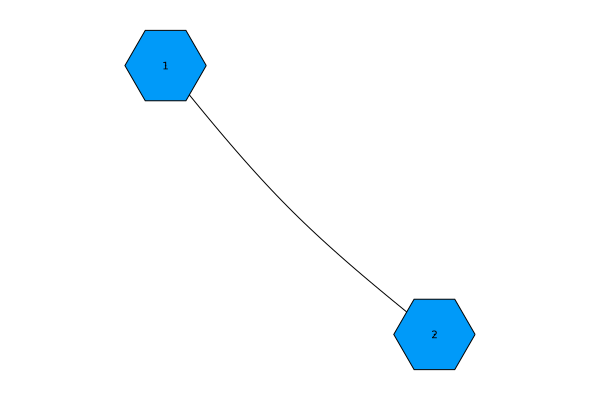

In [24]:
g = gmake(2);
GraphRecipes.graphplot(g,names=1:2,nodesize=0.3)

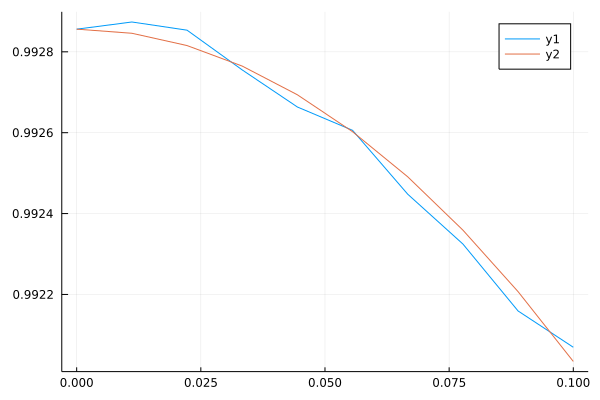

In [33]:
#Theory and simulation
g=CompleteGraph(2)
w=[-1/2,1/2]
k=3.0
u0=[1/2,-1/2]
tf=2000.0
C=rand(2,2)
R0=r2N(soltnN(g,w,k,u0,tf,0,C),tf)
f(σ)=r2N(soltnNOpt(g,w,k,u0,tf,σ),tf)
h(σ)=R0+(1/2)*OptimalC(g,k,w,u0)[2]*σ^2

Plots.plot(LinRange(0,0.1,10),[f,h])

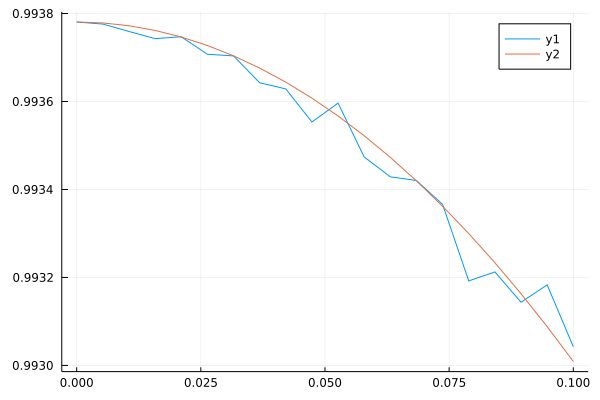

In [58]:
g=CompleteGraph(4)
w=[-1/2,-1/2,1/2,1/2]
k=1.6
u0=[1/2,1/2,-1/2,1/2]
tf=2500.0
C=rand(4,4)
R0=r2N(soltnN(g,w,k,u0,tf,0,C),tf)
f(σ)=r2N(soltnNOpt(g,w,k,u0,tf,σ),tf)
h(σ)=R0+(1/2)*OptimalC(g,k,w,u0)[2]*σ^2

Plots.plot(LinRange(0,0.1,20),[f,h])

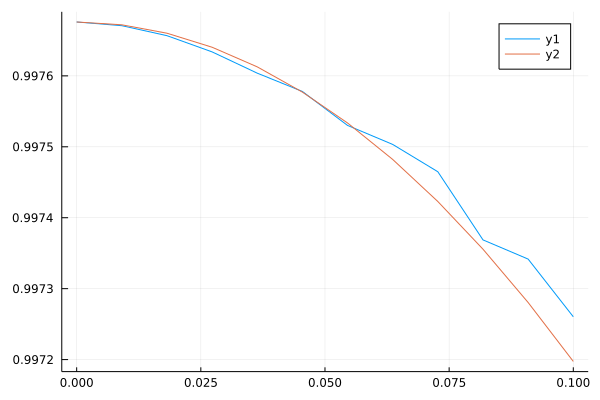

In [61]:
g=CompleteGraph(8)
w=vcat((1/2)*ones(4),(-1/2)*ones(4))
k=1.3
u0=vcat((1/8)*ones(4),(-1/8)*ones(4))
tf=2000.0
C=rand(8,8)
R0=r2N(soltnN(g,w,k,u0,tf,0,C),tf)
f(σ)=r2N(soltnNOpt(g,w,k,u0,tf,σ),tf)
h(σ)=R0+(1/2)*OptimalC(g,k,w,u0)[2]*σ^2

Plots.plot(LinRange(0,0.1,12),[f,h])

In [19]:
g=CompleteGraph(2)
w=[-1/2,1/2]
k=1.4
u0=rand(2)
tf=500.0
C=[[1,0] [0,1]]
f(t)=r2N(soltnNOpt(g,w,k,u0,t,0.06),t)
h(t)=r2N(soltnN(g,w,k,u0,t,0.06,C),t)
optseries=f.(1:10:tf)
randseries=h.(1:10:tf)

50-element Vector{Float64}:
 0.9459350921002031
 0.9586809714595341
 0.9624322274142012
 0.9637999665347065
 0.9648694350231046
 0.9656512986876925
 0.9654362880507736
 0.9646159896018018
 0.9653034412250724
 0.9653249948445721
 0.9648460639767372
 0.9650200664008318
 0.9653681594454542
 ⋮
 0.9666567517583513
 0.9667522186163094
 0.9666427713211021
 0.9666850090295106
 0.9664258514607454
 0.9663497804348127
 0.9667123889777868
 0.9662493773968562
 0.9664184807542591
 0.9666511995300069
 0.9665205798739049
 0.9665326215115727

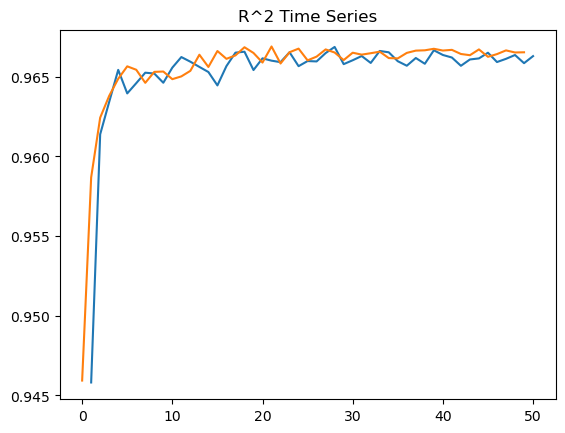

PyObject Text(0.5, 1.0, 'R^2 Time Series')

In [20]:
PyPlot.plot(1:50,optseries,randseries)
title("R^2 Time Series")

# 20 Oscillator 2-Layer Graph

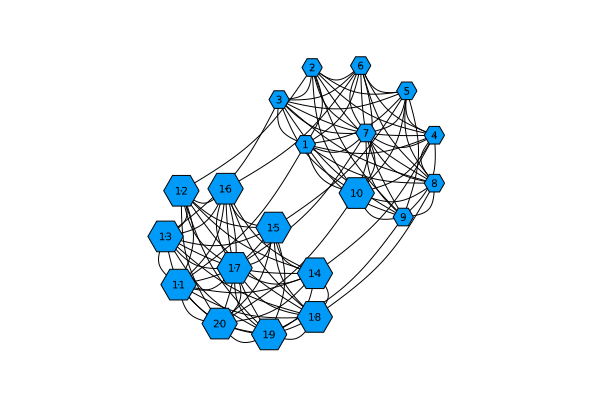

In [65]:
glay=gmake(20)
GraphRecipes.graphplot(glay,names=1:20,nodesize=0.3)

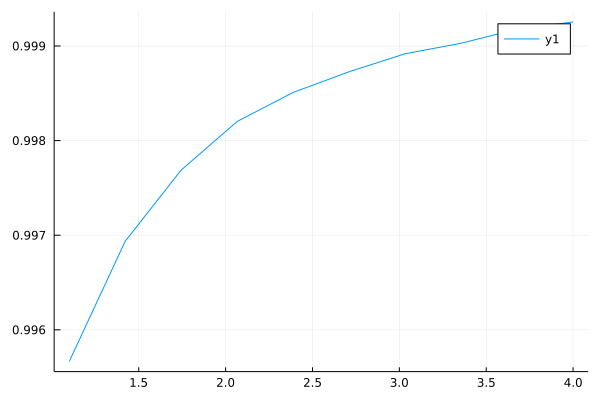

In [68]:
w=vcat((1/2)*ones(10),(-1/2)*ones(10))
u0=rand(20)
tf=100.0
f(k)=r2N(soltnNOpt(glay,w,k,u0,tf,0.5),tf)
Plots.plot(LinRange(1.1,4,10),f)

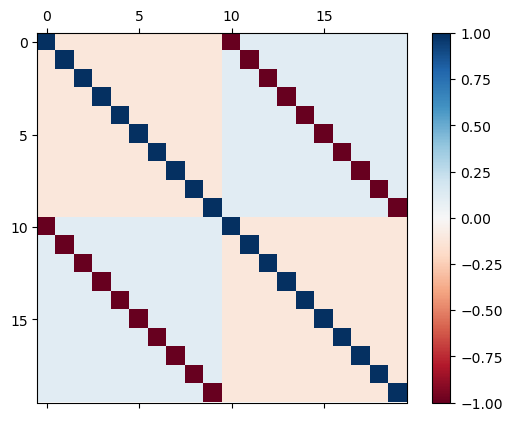

PyObject <matplotlib.colorbar.Colorbar object at 0x7fcf23210490>

In [87]:
tf=100.0

w=vcat((1/2)*ones(10),(-1/2)*ones(10))
u0=rand(20)
C=OptimalC(glay,1.6,w,u0)[1];

fig, ax = subplots()
sc = ax.matshow(C, vmin=-1, vmax=1, cmap="RdBu")
fig.colorbar(sc, ax=ax)

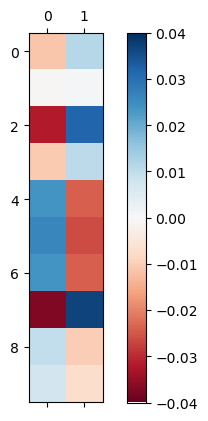

PyObject <matplotlib.colorbar.Colorbar object at 0x7fcf2944ba00>

In [105]:
C=OptimalC(glay,1.6,w,u0)[1]
σ=0.1
Noise=(σ/sqrt(2))*G_generate(C)*rand(20)

Noisemat=[Noise[1:10] Noise[11:20]]

fig, ax = subplots()
sc = ax.matshow(Noisemat, vmin=-0.04, vmax=0.04, cmap="RdBu")
fig.colorbar(sc, ax=ax)

# Bipartite Graph

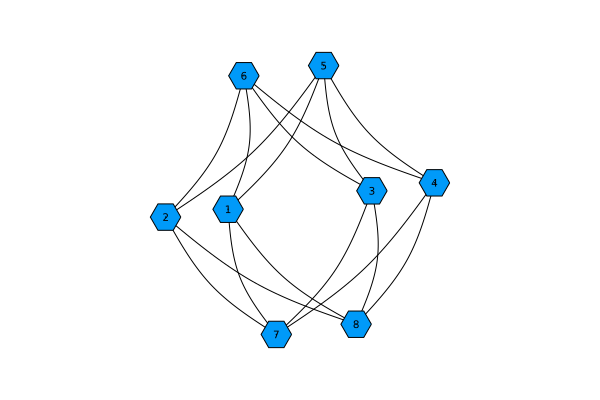

In [115]:
gpart=LightGraphs.complete_bipartite_graph(4, 4)
GraphRecipes.graphplot(gpart,names=1:8,nodesize=0.3)

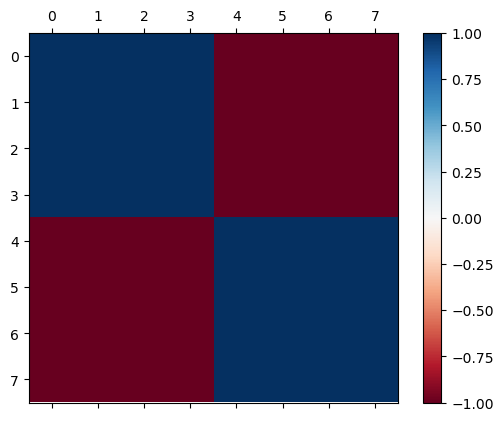

PyObject <matplotlib.colorbar.Colorbar object at 0x7fcf282f7910>

In [132]:
u0=rand(nv(gpart))
k=1.5

w=rand(nv(gpart))
w=w .- mean(w)

C=OptimalC(gpart,k,w,u0)[1];
fig, ax = subplots()

sc = ax.matshow(C, vmin=-1, vmax=1, cmap="RdBu")
fig.colorbar(sc, ax=ax)

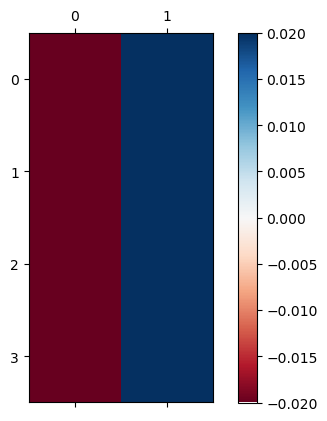

PyObject <matplotlib.colorbar.Colorbar object at 0x7fcf26aeb700>

In [139]:
k=1.5
C=OptimalC(gpart,k,w,u0)[1]
σ=0.1
Noise=(σ/sqrt(2))*G_generate(C)*rand(8)

Noisemat=[Noise[1:4] Noise[5:8]]

fig, ax = subplots()
sc = ax.matshow(Noisemat, vmin=-0.02, vmax=0.02, cmap="RdBu")
fig.colorbar(sc, ax=ax)

# Cycle Graph

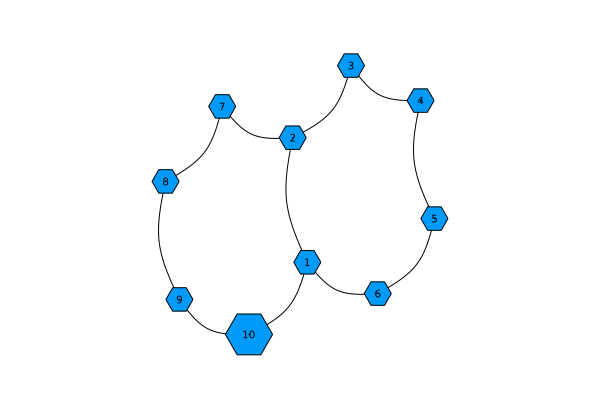

In [161]:
gcycle=LightGraphs.SimpleGraphs.cycle_graph(6)
add_vertex!(gcycle)
add_edge!(gcycle,2,7)
for i in 8:10
    add_vertex!(gcycle)
    add_edge!(gcycle,i-1,i)
end
add_edge!(gcycle,10,1)
GraphRecipes.graphplot(gcycle,names=1:nv(gcycle),nodesize=0.3)

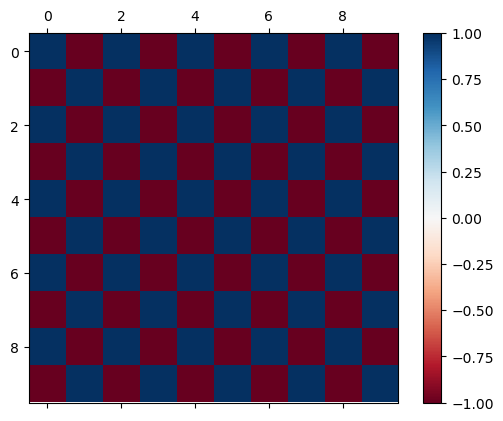

PyObject <matplotlib.colorbar.Colorbar object at 0x7fcf26a18340>

In [162]:
u0=rand(nv(gcycle))
k=1.5

w=rand(nv(gcycle))
w=w .- mean(w)

C=OptimalC(gcycle,k,w,u0)[1];
fig, ax = subplots()

sc = ax.matshow(C, vmin=-1, vmax=1, cmap="RdBu")
fig.colorbar(sc, ax=ax)

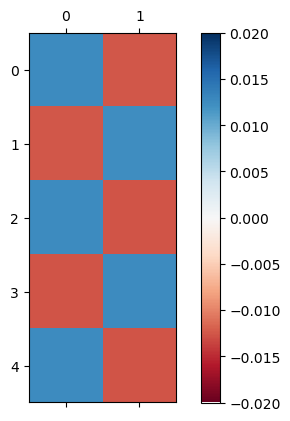

PyObject <matplotlib.colorbar.Colorbar object at 0x7fcf262199a0>

In [164]:
k=1.5
C=OptimalC(gcycle,k,w,u0)[1]
σ=0.1
Noise=(σ/sqrt(2))*G_generate(C)*rand(10)

Noisemat=[Noise[1:5] Noise[6:10]]

fig, ax = subplots()
sc = ax.matshow(Noisemat, vmin=-0.02, vmax=0.02, cmap="RdBu")
fig.colorbar(sc, ax=ax)

# Triangle Graph

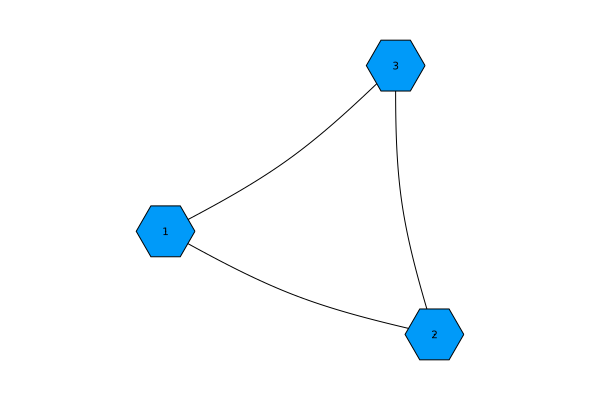

In [173]:
gtriang=gmake(2)
add_vertex!(gtriang)
add_edge!(gtriang,1,3)
add_edge!(gtriang,2,3)
GraphRecipes.graphplot(gtriang,names=1:nv(gtriang),nodesize=0.3)

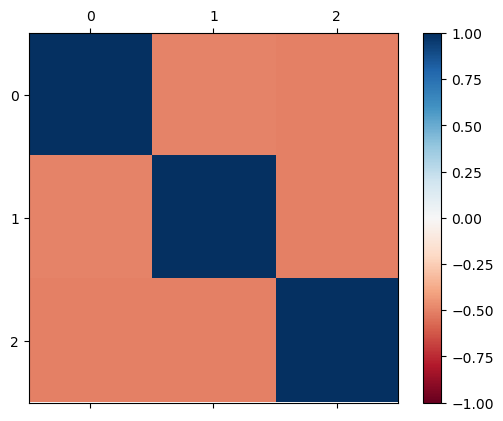

PyObject <matplotlib.colorbar.Colorbar object at 0x7fcf25ad7be0>

In [176]:
u0=rand(nv(gtriang))
k=1.5

w=rand(nv(gtriang))
w=w .- mean(w)

C=OptimalC(gtriang,k,w,u0)[1];
fig, ax = subplots()

sc = ax.matshow(C, vmin=-1, vmax=1, cmap="RdBu")
fig.colorbar(sc, ax=ax)

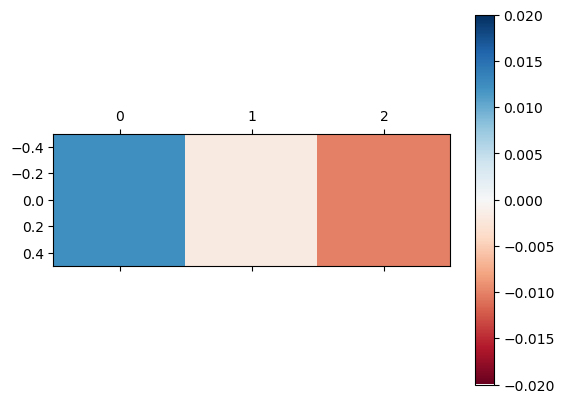

true

In [191]:
k=1.5
C=OptimalC(gtriang,k,w,u0)[1]
σ=0.1
Noise=(σ/sqrt(2))*G_generate(C)*rand(3)

Noisemat=[Noise[1:3]]

fig, ax = subplots()
sc = ax.matshow(Noisemat, vmin=-0.02, vmax=0.02, cmap="RdBu")
fig.colorbar(sc, ax=ax)
print(isposdef(G_generate(C)))

# Erdos Renyi

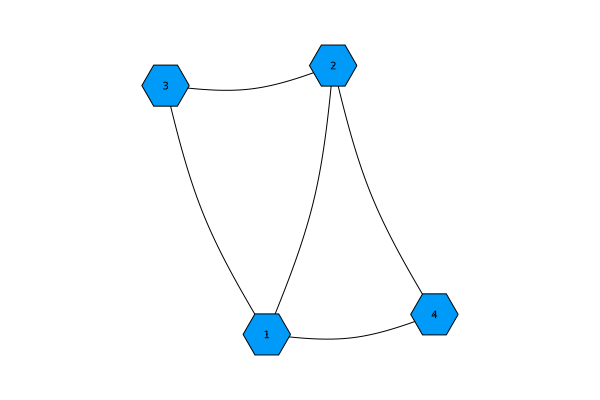

In [28]:
gER=LightGraphs.erdos_renyi(4,0.8)
GraphRecipes.graphplot(gER,names=1:nv(gER),nodesize=0.3)

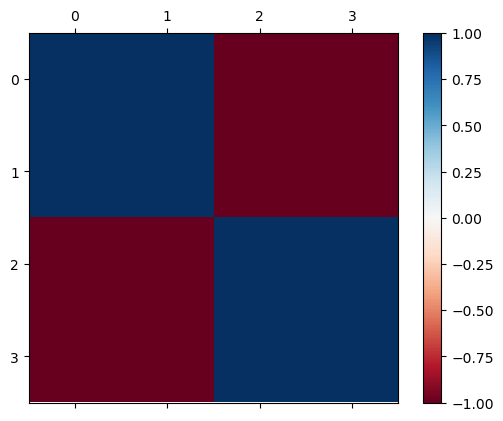

converged(sln) = true


PyObject <matplotlib.colorbar.Colorbar object at 0x7fad01ad54c0>

In [29]:
u0=rand(nv(gER))
k=1.5

w=rand(nv(gER))
w=w .- mean(w)

C=OptimalC(gER,k,w,u0)[1];
fig, ax = subplots()

sc = ax.matshow(C, vmin=-1, vmax=1, cmap="RdBu")
fig.colorbar(sc, ax=ax)

converged(sln) = true


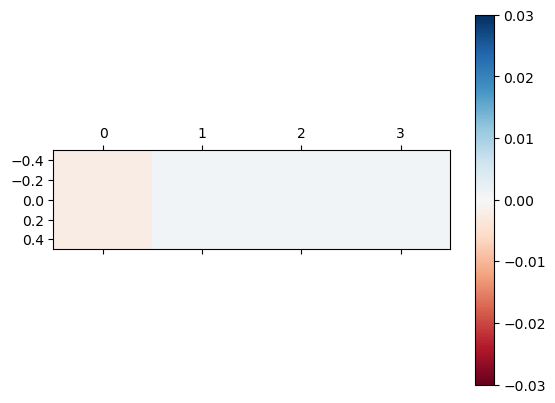

[-1.5216731650264072e-6, -7.247079721359191e-7, 0.004926548643717061, 3.9950756977602273]

In [33]:
k=1.5
C=OptimalC(gER,k,w,u0)[1]
σ=0.1
Noise=(σ/sqrt(2))*G_generate(C)*rand(nv(gER))

Noisemat=[Noise[1:nv(gER)]]

fig, ax = subplots()
sc = ax.matshow(Noisemat, vmin=-0.03, vmax=0.03, cmap="RdBu")
fig.colorbar(sc, ax=ax)
print(eigvals(C))